# Experiment 3: Logistic Regression on Pima Indians Diabetes Dataset
## Aim
Predict the likelihood of diabetes using Logistic Regression and compare model performance with and without feature scaling.

## Theory
Logistic Regression models the probability of a binary outcome using the sigmoid function. It is well suited for classification tasks such as disease prediction. Feature scaling (standardization) rescales features to zero mean and unit variance, which can affect the convergence speed and coefficient magnitudes of the gradient-based solver, and is generally recommended for logistic regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

/home/student/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load and Preprocess the Dataset

In [2]:
url='https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df=pd.read_csv(url,header=None,names=cols)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(df.shape)
df.info()
df.describe()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Columns like Glucose, BloodPressure, SkinThickness, Insulin and BMI cannot be zero physiologically. These zeros are treated as missing values and imputed with the column median.

In [4]:
zero_cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[zero_cols]=df[zero_cols].replace(0,np.nan)
print(df.isnull().sum())
df[zero_cols]=df[zero_cols].fillna(df[zero_cols].median())
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(614, 8) (154, 8)


## Logistic Regression without Feature Scaling

In [6]:
model_raw=LogisticRegression(max_iter=1000)
model_raw.fit(X_train,y_train)
y_pred_raw=model_raw.predict(X_test)

acc_raw=accuracy_score(y_test,y_pred_raw)
prec_raw=precision_score(y_test,y_pred_raw)
rec_raw=recall_score(y_test,y_pred_raw)
f1_raw=f1_score(y_test,y_pred_raw)

print('Without Scaling')
print('Accuracy :',acc_raw)
print('Precision:',prec_raw)
print('Recall   :',rec_raw)
print('F1-score :',f1_raw)
print()
print(classification_report(y_test,y_pred_raw))

Without Scaling
Accuracy : 0.7012987012987013
Precision: 0.5869565217391305
Recall   : 0.5
F1-score : 0.54

              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



## Logistic Regression with Feature Scaling

In [7]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

model_scaled=LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled,y_train)
y_pred_scaled=model_scaled.predict(X_test_scaled)

acc_scaled=accuracy_score(y_test,y_pred_scaled)
prec_scaled=precision_score(y_test,y_pred_scaled)
rec_scaled=recall_score(y_test,y_pred_scaled)
f1_scaled=f1_score(y_test,y_pred_scaled)

print('With Scaling')
print('Accuracy :',acc_scaled)
print('Precision:',prec_scaled)
print('Recall   :',rec_scaled)
print('F1-score :',f1_scaled)
print()
print(classification_report(y_test,y_pred_scaled))

With Scaling
Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5454545454545454

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## Comparison of Performance Metrics

In [8]:
results=pd.DataFrame({
    'Without Scaling':[acc_raw,prec_raw,rec_raw,f1_raw],
    'With Scaling':[acc_scaled,prec_scaled,rec_scaled,f1_scaled]
},index=['Accuracy','Precision','Recall','F1-score'])
results

,Without Scaling,With Scaling
Accuracy,0.701299,0.707792
Precision,0.586957,0.600000
Recall,0.500000,0.500000
F1-score,0.540000,0.545455


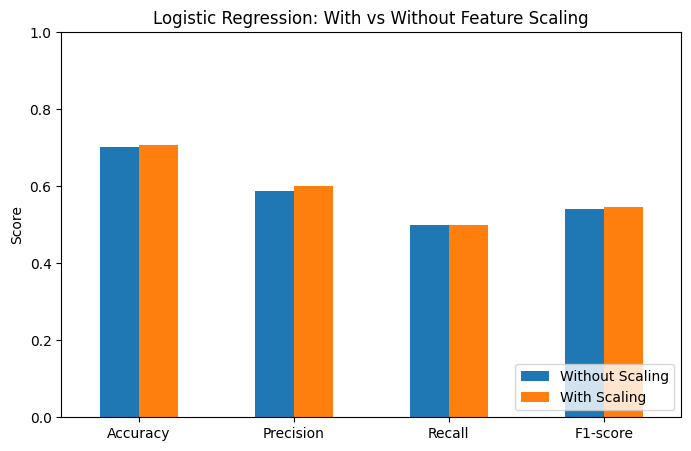

In [9]:
results.plot(kind='bar',figsize=(8,5))
plt.ylabel('Score')
plt.title('Logistic Regression: With vs Without Feature Scaling')
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()

## Confusion Matrices

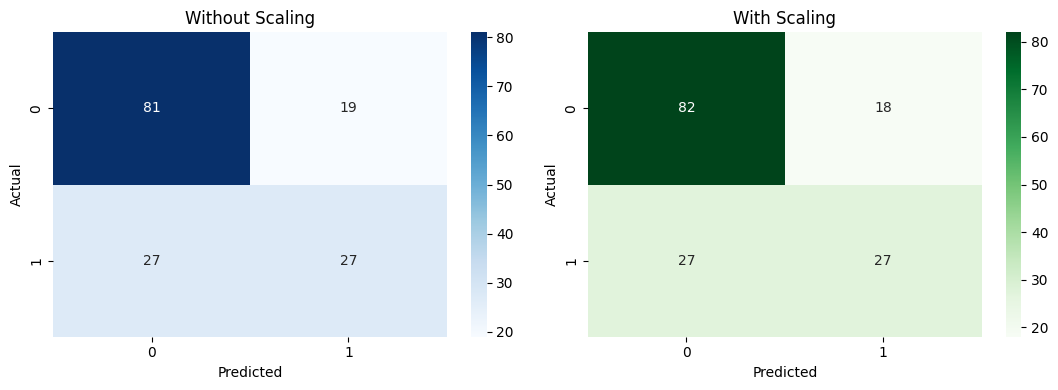

In [10]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.heatmap(confusion_matrix(y_test,y_pred_raw),annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Without Scaling')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test,y_pred_scaled),annot=True,fmt='d',cmap='Greens',ax=axes[1])
axes[1].set_title('With Scaling')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Conclusion
Logistic Regression was trained on the Pima Indians Diabetes dataset both with and without feature scaling. Since Logistic Regression uses a gradient-based solver, standardizing the features (zero mean, unit variance) speeds up convergence and can slightly change the accuracy, precision, recall and F1-score. Comparing the two sets of metrics shows whether scaling improved the model's ability to correctly identify diabetic and non-diabetic cases.